<a href="https://colab.research.google.com/github/salsilsulselsol/Associate-Data-Scientist-Python-Nasional-Notes-Experiment/blob/main/07_scikit_learn_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 07: Machine Learning with Scikit-learn
**Course:** Associate Data Scientist + Python - Nasional   
**Objective:** Implementing end-to-end Machine Learning pipelines, including preprocessing, model selection, hyperparameter tuning, and ensemble methods.

## 1. Predictive Modeling Pipeline
The fundamental workflow of Machine Learning involves data exploration, splitting, and training.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing

# 1.1 Load and Explore Tabular Data
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

In [3]:
# 1.2 Training on Numerical Data
X = df[['MedInc']] # Using Median Income as predictor
y = df['target']   # Median House Value

# Splitting data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and Predict
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred)}")

MSE: 0.7091157771765549


## 2. Handling Categorical Data
Machine Learning models require numerical input. We use Encoding for categorical variables.

In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Example of a preprocessing and modeling pipeline
categorical_cols = ['ocean_proximity']
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(), categorical_cols)])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

## 3. Model Selection and Generalization
Finding the balance between bias and variance is key to building models that generalize well to new data.

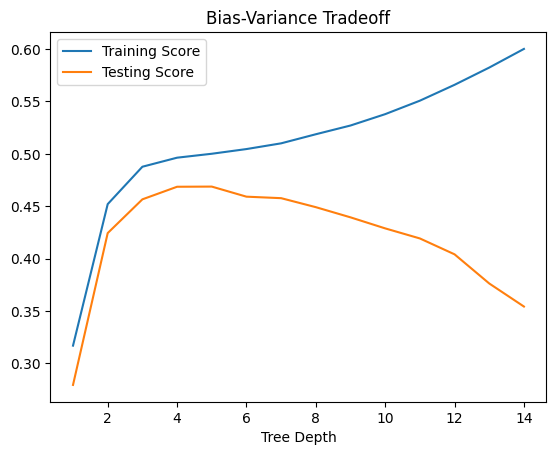

In [5]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Analyzing max_depth to observe Overfitting/Underfitting
train_scores, test_scores = [], []
depths = range(1, 15)

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

plt.plot(depths, train_scores, label='Training Score')
plt.plot(depths, test_scores, label='Testing Score')
plt.xlabel('Tree Depth')
plt.legend()
plt.title('Bias-Variance Tradeoff')
plt.show()

## 4. Hyperparameter Tuning
Automating the search for the best model parameters using Grid Search.

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}


## 5. Linear and Regularized Models
Linear models are efficient. Regularization (Ridge/Lasso) prevents overfitting by penalizing large coefficients.

In [10]:
from sklearn.linear_model import Ridge, LogisticRegression

# Ridge Regression (L2 Regularization)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Logistic Regression for Classification
# log_reg = LogisticRegression()
# log_reg.fit(X_train_class, y_train_class)

Ridge()

## 6. Tree-based and Ensemble Models
Ensemble methods like Random Forest and Gradient Boosting combine multiple models for superior performance.

In [11]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Random Forest (Bagging)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Gradient Boosting (Boosting)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)
gb.fit(X_train, y_train)

print(f"RF Score: {rf.score(X_test, y_test)}")
print(f"GB Score: {gb.score(X_test, y_test)}")

RF Score: 0.28171270917366775
GB Score: 0.46829549825787053


## 7. Model Evaluation Metrics
Evaluating model performance using various metrics for regression and classification.

In [12]:
from sklearn.metrics import classification_report, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score

# Regression Metrics
y_pred_rf = rf.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred_rf)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf)}")

# Classification Evaluation (Example)
# print(classification_report(y_test_class, y_pred_class))

# Cross-Validation
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"Cross-Val Mean Score: {cv_scores.mean()}")

R2 Score: 0.28171270917366775
MAE: 0.7131670294859699
Cross-Val Mean Score: 0.2409603983517349
